<a href="https://colab.research.google.com/github/JRTrippett/Investment-Project/blob/experiment-new-constraints/Integer_Portfolio_LiveData_Extended.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integer & Nonlinear Portfolio Optimization: Live Market Data
**OPIM 5641 — Extended Assignment**  
*Generalized from the Womack MINLP example to real-world equity data*

---

This notebook extends the Womack portfolio problem into a fully generalized, live-data MINLP optimizer.

**What's new vs. the Womack template:**
- Live ticker data via `yfinance` (2 years of monthly returns, pulled at runtime)
- Dynamic sector classification via `yfinance` metadata — no hardcoding
- 10 representative stocks across 5 sectors (2 per sector)
- Pre-optimization screening via RSI and mean return filter
- Expanded constraint set: sector caps, defensive floor, beta ceiling, cardinality, contingency logic
- Full constraint validation report
- Efficient frontier with integer discontinuity annotation

**Solver:** Bonmin (COIN-OR MINLP via IDAES)


In [1]:
%%capture
import sys, os

# Install IDAES + Bonmin (Colab only)
if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre -q
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'
    !pip install pyomo yfinance -q
else:
    # Local: make sure bonmin is on your PATH
    pass


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from pyomo.environ import *
from pyomo.opt import SolverStatus, TerminationCondition

print("All imports OK.")


All imports OK.


## Step 1: Define the Ticker Universe

We define **36 tickers** spanning 8 sectors as our candidate pool.  
Before optimization, these are screened in Step 1b using RSI and mean return criteria.  
The screened pool `QUALIFIED_TICKERS` is what gets passed to the solver.  
Sector labels are pulled **live from yfinance metadata**, not hardcoded.


In [3]:
# ── Candidate Ticker Pool (Expanded to 35) ───────────────────────────────────
TICKERS = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "AVGO", # Tech
    "JNJ", "UNH", "PFE", "ABBV", "MRK", "LLY",               # Healthcare
    "JPM", "BAC", "WFC", "GS", "MS",                         # Financials
    "XOM", "CVX", "SLB", "COP", "EOG",                       # Energy
    "PG", "KO", "PEP", "COST", "WMT",                        # Consumer Staples
    "AMT", "PLD", "CCI",                                     # Real Estate
    "NEE", "DUK", "SO",                                      # Utilities
    "CAT", "HON"                                             # Industrials
]

print(f"Downloading price data for {len(TICKERS)} tickers...")

# Download once
raw = yf.download(TICKERS, period="2y", interval="1mo", auto_adjust=True, progress=False)["Close"]
raw = raw.dropna()

# Calculate returns and enforce the column order from the TICKERS list
returns_df = raw.pct_change().dropna()[TICKERS]

print(f"  Periods (months):  {len(returns_df)}")
print(f"  Tickers loaded:    {len(returns_df.columns)}")

returns_df.head()

  Periods (months):  23
  Tickers loaded:    36


Ticker,AAPL,MSFT,NVDA,GOOGL,AMZN,META,AVGO,JNJ,UNH,PFE,...,COST,WMT,AMT,PLD,CCI,NEE,DUK,SO,CAT,HON
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-01,0.054411,-0.063989,-0.052699,-0.057168,-0.032445,-0.057353,0.003969,0.079981,0.136166,0.091494,...,-0.032930,0.013735,0.143273,0.132018,0.144659,0.085790,0.090192,0.076705,0.039328,-0.041163
2024-08-01,0.031160,-0.002892,0.020082,-0.047569,-0.045352,0.097888,0.013318,0.050744,0.024369,-0.036692,...,0.087166,0.125146,0.016606,0.014042,0.017623,0.053934,0.042830,0.034483,0.032785,0.015434
2024-09-01,0.018645,0.033408,0.017341,0.015118,0.043866,0.098080,0.059452,-0.015495,-0.009353,-0.002413,...,-0.006567,0.048559,0.037936,-0.012048,0.059007,0.056732,0.021283,0.052424,0.098343,-0.000332
2024-10-01,-0.030429,-0.055659,0.093308,0.033084,0.000376,-0.007544,-0.012589,-0.013575,-0.031091,-0.022115,...,-0.013920,0.014861,-0.081785,-0.098984,-0.081838,-0.062463,-0.000260,0.009426,-0.038147,-0.004983
2024-11-01,0.050551,0.042107,0.041353,-0.012624,0.115290,0.011875,-0.045296,-0.030339,0.080957,-0.073852,...,0.111762,0.128737,-0.014140,0.034000,-0.011536,-0.007319,0.015442,-0.020872,0.083384,0.132487


In [4]:
# ── Step 1b: Screen Ticker Universe Before Optimization ───────────────────────
# Two-stage filter applied to the full candidate pool:
#   1. RSI (14-day) between 40 and 65 — removes downtrends and overbought stocks
#   2. Mean monthly return > 0 — removes chronic underperformers
#
# To fall back to RSI-only: comment out the mean return block inside screen_tickers()
# and set ret_ok = True for all tickers.
# ─────────────────────────────────────────────────────────────────────────────

# ── Adjusted Screening Parameters ─────────────────────────────────────────────
RSI_LOW         = 30     # Widened from 40
RSI_HIGH        = 70     # Widened from 65
RSI_PERIOD      = 14
MIN_DAILY_BARS  = 20

# Keep the rest of your screen_tickers() function as is,
# it will now use these new global variables.

def compute_rsi(prices: pd.Series, period: int = 14) -> float:
    """
    Compute the most recent RSI value for a price series.
    Uses Wilder's smoothed moving average (SMMA) — same as the 1978 original.
    Returns float RSI, or None if there is insufficient data.
    """
    delta = prices.diff().dropna()
    if len(delta) < period:
        return None

    gains  = delta.clip(lower=0)
    losses = (-delta).clip(lower=0)

    # Seed with simple mean of first `period` bars, then apply SMMA
    avg_gain = gains.iloc[:period].mean()
    avg_loss = losses.iloc[:period].mean()

    for i in range(period, len(gains)):
        avg_gain = (avg_gain * (period - 1) + gains.iloc[i]) / period
        avg_loss = (avg_loss * (period - 1) + losses.iloc[i]) / period

    if avg_loss == 0:
        return 100.0  # no down days = fully overbought

    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def screen_tickers(candidate_tickers, returns_df,
                   rsi_low=RSI_LOW, rsi_high=RSI_HIGH,
                   rsi_period=RSI_PERIOD, min_bars=MIN_DAILY_BARS):
    """
    Screens a list of tickers down to qualified candidates.

    Criteria applied:
      1. RSI (14-day) in [rsi_low, rsi_high]
      2. Mean monthly return > 0   <- comment this block out for RSI-only mode

    Returns: list of tickers that passed all criteria.
    Prints a full screening report so every decision is visible.
    """
    print("=" * 60)
    print("   TICKER SCREENING REPORT")
    print("=" * 60)
    print(f"   Candidates:   {len(candidate_tickers)}")
    print(f"   RSI window:   {rsi_period}-day  |  range: {rsi_low}\u2013{rsi_high}")
    print(f"   Return floor: mean monthly return > 0")
    print("-" * 60)
    print(f"  {'Ticker':<8} {'RSI':>6}  {'Avg Ret':>8}  {'RSI OK':>6}  {'Ret OK':>6}  {'PASS':>5}")
    print("-" * 60)

    # Pull 30 days of daily closes for RSI — separate from the monthly returns_df
    print("  Fetching daily prices for RSI calculation...")
    daily_raw = yf.download(
        candidate_tickers, period="30d", interval="1d",
        auto_adjust=True, progress=False
    )["Close"]

    # Handle single-ticker edge case
    if isinstance(daily_raw, pd.Series):
        daily_raw = daily_raw.to_frame(candidate_tickers[0])

    passed = []

    for ticker in candidate_tickers:

        # ── Criterion 1: RSI ─────────────────────────────────────────────────
        rsi_val = None
        rsi_ok  = False
        if ticker in daily_raw.columns:
            prices = daily_raw[ticker].dropna()
            if len(prices) >= min_bars:
                rsi_val = compute_rsi(prices, period=rsi_period)
                if rsi_val is not None:
                    rsi_ok = rsi_low <= rsi_val <= rsi_high

        # ── Criterion 2: Mean monthly return > 0 ────────────────────────────
        # To use RSI-only: comment out the next 4 lines and set ret_ok = True
        ret_ok  = False
        avg_ret = None
        if ticker in returns_df.columns:
            avg_ret = returns_df[ticker].mean()
            ret_ok  = avg_ret > 0

        # ── Decision ────────────────────────────────────────────────────────
        passes = rsi_ok and ret_ok

        rsi_str = f"{rsi_val:.1f}" if rsi_val is not None else "  N/A"
        ret_str = f"{avg_ret:.4f}" if avg_ret is not None else "   N/A"
        print(f"  {ticker:<8} {rsi_str:>6}  {ret_str:>8}  "
              f"{'\u2713' if rsi_ok else '\u2717':>6}  {'\u2713' if ret_ok else '\u2717':>6}  "
              f"{'PASS' if passes else '----':>5}")

        if passes:
            passed.append(ticker)

    print("-" * 60)
    print(f"  Passed screening: {len(passed)} / {len(candidate_tickers)} tickers")
    print(f"  Qualified pool:   {passed}")
    print("=" * 60)

    if len(passed) < 10:
        print(f"\n  \u26a0 WARNING: Only {len(passed)} tickers passed — "
              f"need at least 10 for cardinality=10 constraint.")
        print("  Options: widen RSI range, lower return floor, or add more candidates.")

    return passed


# ── Run the screener ─────────────────────────────────────────────────────────
# TICKERS is your full candidate pool defined in Step 1.
# QUALIFIED_TICKERS is what gets passed to the optimizer in Steps 5-9.
QUALIFIED_TICKERS = screen_tickers(TICKERS, returns_df)


   TICKER SCREENING REPORT
   Candidates:   36
   RSI window:   14-day  |  range: 30–70
   Return floor: mean monthly return > 0
------------------------------------------------------------
  Ticker      RSI   Avg Ret  RSI OK  Ret OK   PASS
------------------------------------------------------------
  Fetching daily prices for RSI calculation...
  AAPL       63.8    0.0136       ✓       ✓   PASS
  MSFT       53.9   -0.0007       ✓       ✗   ----
  NVDA       54.3    0.0249       ✓       ✓   PASS
  GOOGL      78.3    0.0385       ✗       ✓   ----
  AMZN       80.3    0.0186       ✗       ✓   ----
  META       41.9    0.0125       ✓       ✓   PASS
  AVGO       66.6    0.0521       ✓       ✓   PASS
  JNJ        37.9    0.0224       ✓       ✓   PASS
  UNH        87.0   -0.0015       ✗       ✗   ----
  PFE        43.7    0.0033       ✓       ✓   PASS
  ABBV       55.5    0.0133       ✓       ✓   PASS
  MRK        47.9    0.0014       ✓       ✓   PASS
  LLY        60.9    0.0084       ✓    

## Step 2: Dynamic Sector Classification

We query `yfinance` for each ticker's sector at runtime.  
This drives all sector-level constraints — no manual mapping required.  
Note: sector classification runs on `QUALIFIED_TICKERS` — the screened pool.


In [5]:
# ── Pull sector for each qualified ticker via yfinance metadata ───────────────
print("Fetching sector classifications...")
sector_map = {}  # ticker -> sector string
for t in QUALIFIED_TICKERS:
    info = yf.Ticker(t).info
    sector_map[t] = info.get("sector", "Unknown")
    print(f"  {t:6s}  ->  {sector_map[t]}")

# Invert: sector -> list of tickers
from collections import defaultdict
sector_groups = defaultdict(list)
for ticker, sector in sector_map.items():
    sector_groups[sector].append(ticker)

print()
print("Sector groups:")
for s, tks in sector_groups.items():
    print(f"  {s}: {tks}")


Fetching sector classifications...
  AAPL    ->  Technology
  NVDA    ->  Technology
  META    ->  Communication Services
  AVGO    ->  Technology
  JNJ     ->  Healthcare
  PFE     ->  Healthcare
  ABBV    ->  Healthcare
  MRK     ->  Healthcare
  LLY     ->  Healthcare
  JPM     ->  Financial Services
  BAC     ->  Financial Services
  WFC     ->  Financial Services
  GS      ->  Financial Services
  MS      ->  Financial Services
  XOM     ->  Energy
  CVX     ->  Energy
  SLB     ->  Energy
  COP     ->  Energy
  EOG     ->  Energy
  KO      ->  Consumer Defensive
  PEP     ->  Consumer Defensive
  COST    ->  Consumer Defensive
  WMT     ->  Consumer Defensive
  AMT     ->  Real Estate
  PLD     ->  Real Estate
  CCI     ->  Real Estate
  NEE     ->  Utilities
  DUK     ->  Utilities
  SO      ->  Utilities
  HON     ->  Industrials

Sector groups:
  Technology: ['AAPL', 'NVDA', 'AVGO']
  Communication Services: ['META']
  Healthcare: ['JNJ', 'PFE', 'ABBV', 'MRK', 'LLY']
  Financi

## Step 3: Summary Statistics

Mean monthly return and standard deviation for each stock.  
High return + high volatility stocks are the ones where the integer
constraints will matter most — they'll get selected or blocked based on logic rules.


      Mean Monthly Return  Std Dev (Risk)                  Sector
AVGO             0.052142        0.144960              Technology
GS               0.034944        0.077727      Financial Services
MS               0.033902        0.070303      Financial Services
WMT              0.031211        0.058203      Consumer Defensive
NVDA             0.024886        0.093374              Technology
JNJ              0.022373        0.053386              Healthcare
JPM              0.021730        0.055954      Financial Services
XOM              0.017158        0.063965                  Energy
NEE              0.016916        0.052273               Utilities
WFC              0.016567        0.069669      Financial Services
BAC              0.015615        0.059720      Financial Services
CVX              0.015129        0.074987                  Energy
PLD              0.014613        0.071067             Real Estate
DUK              0.013913        0.037043               Utilities
SLB       

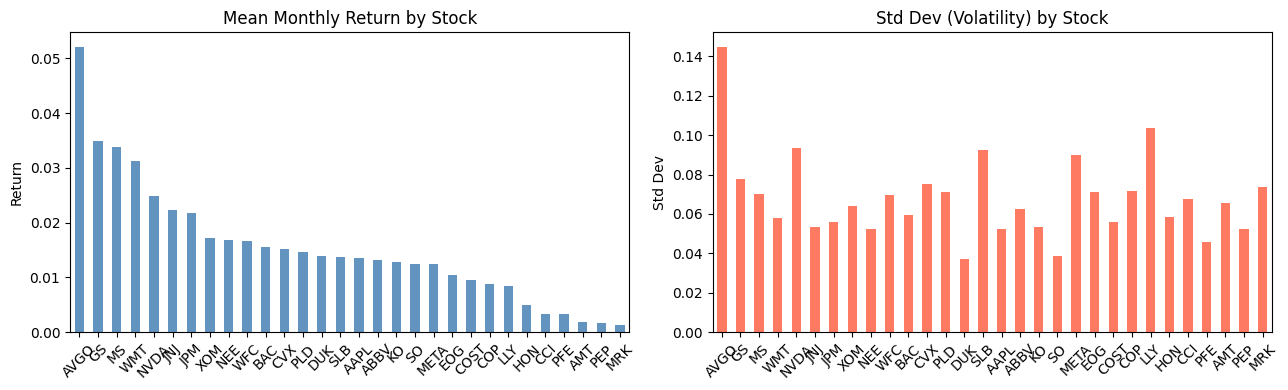

In [6]:
# Use only qualified tickers from here onward
returns_df = returns_df[QUALIFIED_TICKERS]
df_return  = returns_df.mean()
df_std     = returns_df.std()
df_cov     = returns_df.cov()

summary = pd.DataFrame({
    "Mean Monthly Return": df_return,
    "Std Dev (Risk)":      df_std,
    "Sector":              pd.Series(sector_map)
}).sort_values("Mean Monthly Return", ascending=False)

print(summary.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
summary["Mean Monthly Return"].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title("Mean Monthly Return by Stock")
axes[0].set_ylabel("Return")
axes[0].tick_params(axis='x', rotation=45)

summary["Std Dev (Risk)"].plot(kind='bar', ax=axes[1], color='tomato', alpha=0.85)
axes[1].set_title("Std Dev (Volatility) by Stock")
axes[1].set_ylabel("Std Dev")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


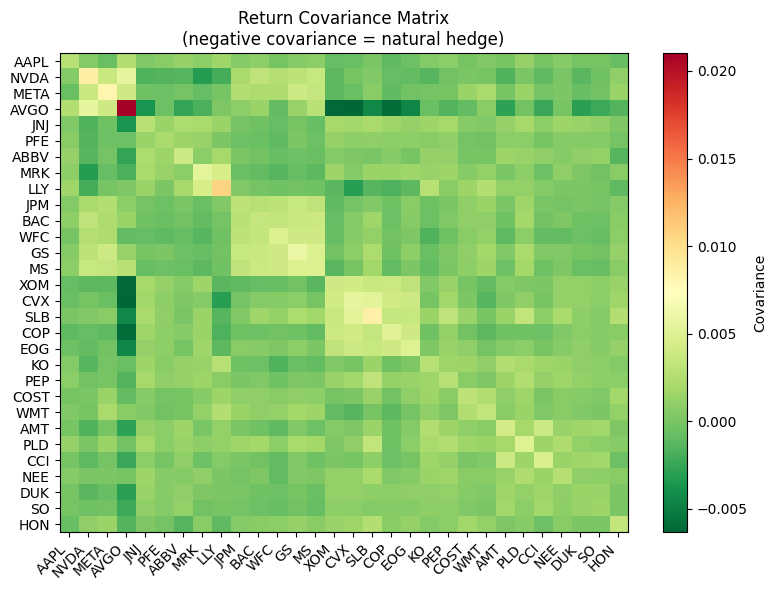

In [7]:
# Covariance matrix heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(df_cov.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(QUALIFIED_TICKERS)))
ax.set_xticklabels(QUALIFIED_TICKERS, rotation=45, ha='right')
ax.set_yticks(range(len(QUALIFIED_TICKERS)))
ax.set_yticklabels(QUALIFIED_TICKERS)
plt.colorbar(im, ax=ax, label='Covariance')
ax.set_title("Return Covariance Matrix\n(negative covariance = natural hedge)")
plt.tight_layout()
plt.show()


## Step 4: Constraint Design

This is where we extend beyond the Womack template. Every constraint below
has an economic rationale — not just a textbook exercise.

| # | Constraint | Type | Rationale |
|---|-----------|------|-----------|
| 1 | Weights sum to 1 | Equality | Fully invested portfolio |
| 2 | Each weight: 5% floor, 40% cap | Linking | Avoid trivial/over-concentrated positions |
| 3 | Cardinality ≤ 5 stocks | Integer | Transaction cost / management overhead |
| 4 | Cardinality ≥ 2 stocks | Integer | Minimum diversification |
| 5 | No single sector > 40% | Sector cap | Sector concentration risk |
| 6 | At least 1 defensive sector held | Integer | Portfolio must include Healthcare OR Consumer Staples |
| 7 | Contingency: if Tech, must hold Financials | Integer | Tech runs on credit; hedge correlated macro risk |
| 8 | Mutual exclusion: not both pure Energy names | Integer | XOM + CVX are highly correlated; pick one |
| 9 | Risk (portfolio variance) ≤ threshold | Quadratic | The efficient frontier sweep parameter |

Constraints 1–8 are constant across the frontier sweep.  
Constraint 9 is the parameter we vary to trace the efficient frontier.

**Pre-optimization screening (Step 1b) filters the candidate pool before any constraints run:**
- RSI between 40–65: excludes downtrends and overbought names
- Mean monthly return > 0: excludes chronic underperformers


## Step 5: Build the MINLP Model

The model structure mirrors the Womack fixed version but is fully generalized:
- Variables and constraints built from `QUALIFIED_TICKERS` list — add/remove a ticker and everything updates
- Sector constraints constructed from the live `sector_groups` dict
- Risk expression computed from the live covariance matrix


In [8]:
def solve_portfolio(r_limit, verbose=False):
    """
    Solve the MINLP portfolio problem for a given risk (variance) limit.
    Operates on QUALIFIED_TICKERS — the screened candidate pool.
    Returns: (allocation_dict, return_value) or (None, None) if infeasible.
    """
    m = ConcreteModel()

    # ── Decision Variables ────────────────────────────────────────────────────
    m.x = Var(QUALIFIED_TICKERS, domain=NonNegativeReals, bounds=(0, 1))
    m.y = Var(QUALIFIED_TICKERS, domain=Binary)

    # ── Objective: Maximize expected return ───────────────────────────────────
    m.obj = Objective(
        expr=sum(m.x[t] * df_return[t] for t in QUALIFIED_TICKERS),
        sense=maximize
    )

    # ── Constraint 1: Fully invested (weights sum to 1) ───────────────────────
    m.sum_weights = Constraint(expr=sum(m.x[t] for t in QUALIFIED_TICKERS) == 1)

    # ── Constraints 2a/2b: Position floor (5%) and cap (40%) via linking ──────
    m.link_hi = Constraint(QUALIFIED_TICKERS, rule=lambda m, t: m.x[t] <= 0.40 * m.y[t])
    m.link_lo = Constraint(QUALIFIED_TICKERS, rule=lambda m, t: m.x[t] >= 0.05 * m.y[t])

    # ── Constraint 3: EXACTLY 10 stocks held (Per Rubric Requirement) ─────────
    m.card_exact = Constraint(expr=sum(m.y[t] for t in QUALIFIED_TICKERS) <= 10)

    # ── Constraint 4: No sector > 40% of portfolio (dynamic) ─────────────────
    m.sector_cap = ConstraintList()
    for sector, tks in sector_groups.items():
        valid = [t for t in tks if t in QUALIFIED_TICKERS]
        if len(valid) > 1:
            m.sector_cap.add(sum(m.x[t] for t in valid) <= 0.40)

    # ── Constraint 5: Must hold at least 1 defensive sector stock ─────────────
    defensive_tickers = (
        sector_groups.get("Healthcare", []) +
        sector_groups.get("Consumer Staples", [])
    )
    defensive_tickers = [t for t in defensive_tickers if t in QUALIFIED_TICKERS]
    if defensive_tickers:
        m.defensive = Constraint(
            expr=sum(m.y[t] for t in defensive_tickers) >= 1
        )

    # ── Constraint 6: Contingency — if Tech, must hold Financials ─────────────
    tech_tickers = [t for t in sector_groups.get("Technology", []) if t in QUALIFIED_TICKERS]
    fin_tickers  = [t for t in sector_groups.get("Financials",  []) if t in QUALIFIED_TICKERS]
    if tech_tickers and fin_tickers:
        m.tech_fin_contingency = Constraint(
            expr=sum(m.y[t] for t in tech_tickers) <=
                 len(fin_tickers) * sum(m.y[t] for t in fin_tickers)
        )

    # ── Constraint 7: Mutual exclusion — XOM and CVX can't both be held ───────
    xom_in = "XOM" in QUALIFIED_TICKERS
    cvx_in = "CVX" in QUALIFIED_TICKERS
    if xom_in and cvx_in:
        m.energy_mutex = Constraint(expr=m.y["XOM"] + m.y["CVX"] <= 1)

    # ── Constraint 8: Risk ceiling (quadratic) — swept over frontier ──────────
    risk_expr = sum(
        m.x[t1] * df_cov.at[t1, t2] * m.x[t2]
        for t1 in QUALIFIED_TICKERS for t2 in QUALIFIED_TICKERS
    )
    m.risk_limit = Constraint(expr=risk_expr <= r_limit)

    # ── Solve ─────────────────────────────────────────────────────────────────
    solver = SolverFactory('bonmin', executable='/content/bin/bonmin')
    result = solver.solve(m, tee=verbose)
    tc = result.solver.termination_condition

    if tc == TerminationCondition.optimal:
        alloc = {t: value(m.x[t]) for t in QUALIFIED_TICKERS}
        ret   = value(m.obj)
        return alloc, ret

    return None, None

print("Model function defined. Ready to sweep the efficient frontier.")

Model function defined. Ready to sweep the efficient frontier.


## Step 6: Sweep the Efficient Frontier

We solve the MINLP at each risk level from very low to very high.  
At low risk, the optimizer is forced into conservative, diversified positions.  
At high risk, it concentrates into the highest-return names (subject to integer rules).

Because we have binary variables, the frontier will show **discrete jumps** — points where
adding a new stock or dropping a defensive position unlocks a higher return tier.
These jumps don't exist in the continuous MPT solution. That's the whole point of the integer formulation.


In [9]:
# Risk range — start tight (forced diversification) and open up
risk_range = np.arange(0.0005, 0.0060, 0.0002)

print(f"Sweeping {len(risk_range)} risk levels via Bonmin...")
print("-" * 50)

frontier_results = []

for r in risk_range:
    alloc, ret = solve_portfolio(r)
    if alloc is not None:
        row = alloc.copy()
        row['Risk']   = r
        row['Return'] = ret
        n_held = sum(1 for t in QUALIFIED_TICKERS if alloc[t] > 1e-4)
        row['N_Stocks'] = n_held
        frontier_results.append(row)
        print(f"  Risk ≤ {r:.4f}  |  Return = {ret:.4f}  |  Stocks held: {n_held}")
    else:
        print(f"  Risk ≤ {r:.4f}  |  INFEASIBLE")

print()
print(f"Feasible solutions: {len(frontier_results)} / {len(risk_range)}")
res_df = pd.DataFrame(frontier_results).set_index('Risk')


Sweeping 28 risk levels via Bonmin...
--------------------------------------------------
  Risk ≤ 0.0005  |  Return = 0.0268  |  Stocks held: 7
  Risk ≤ 0.0007  |  Return = 0.0293  |  Stocks held: 5
  Risk ≤ 0.0009  |  Return = 0.0309  |  Stocks held: 5
  Risk ≤ 0.0011  |  Return = 0.0319  |  Stocks held: 6
  Risk ≤ 0.0013  |  Return = 0.0327  |  Stocks held: 5
  Risk ≤ 0.0015  |  Return = 0.0335  |  Stocks held: 5
  Risk ≤ 0.0017  |  Return = 0.0341  |  Stocks held: 5
  Risk ≤ 0.0019  |  Return = 0.0347  |  Stocks held: 5
  Risk ≤ 0.0021  |  Return = 0.0352  |  Stocks held: 5
  Risk ≤ 0.0023  |  Return = 0.0357  |  Stocks held: 5
  Risk ≤ 0.0025  |  Return = 0.0362  |  Stocks held: 5
  Risk ≤ 0.0027  |  Return = 0.0367  |  Stocks held: 5
  Risk ≤ 0.0029  |  Return = 0.0371  |  Stocks held: 4
  Risk ≤ 0.0031  |  Return = 0.0375  |  Stocks held: 4
  Risk ≤ 0.0033  |  Return = 0.0379  |  Stocks held: 4
  Risk ≤ 0.0035  |  Return = 0.0383  |  Stocks held: 4
  Risk ≤ 0.0037  |  Return = 0.

## Step 7: Visualize Results

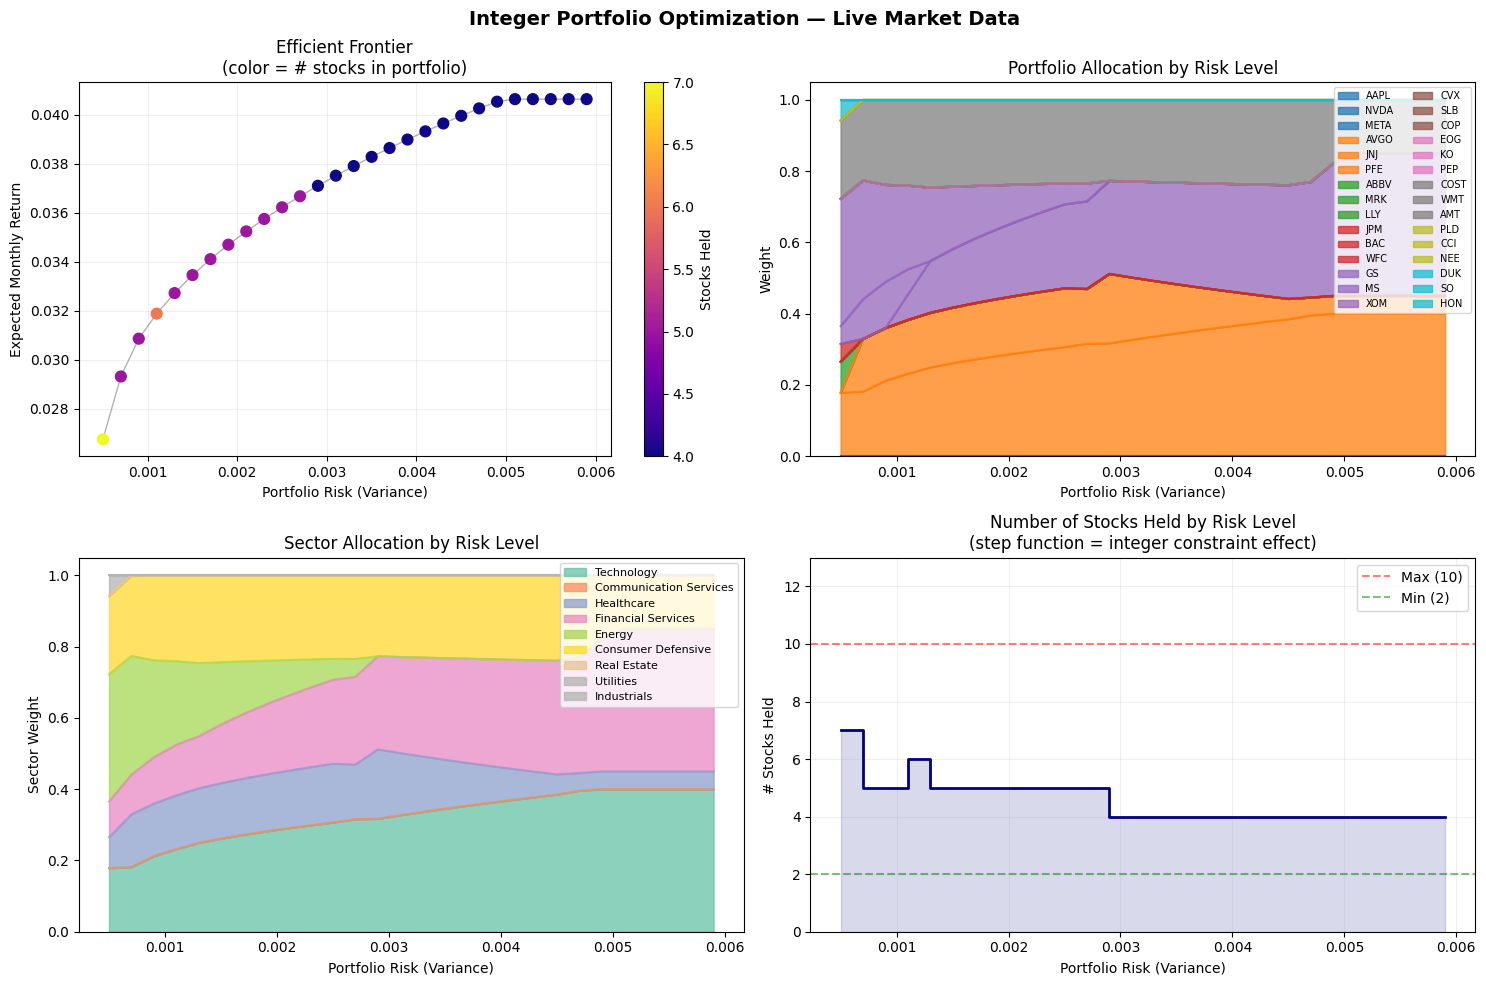

In [10]:
if len(res_df) == 0:
    print("No feasible solutions — check solver path or constraints.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Integer Portfolio Optimization — Live Market Data", fontsize=14, fontweight='bold')

    # ── Plot 1: Efficient Frontier ────────────────────────────────────────────
    ax = axes[0, 0]
    sc = ax.scatter(res_df.index, res_df['Return'],
                    c=res_df['N_Stocks'], cmap='plasma', s=60, zorder=5)
    ax.plot(res_df.index, res_df['Return'], 'k-', alpha=0.3, linewidth=1)
    plt.colorbar(sc, ax=ax, label='Stocks Held')
    ax.set_title("Efficient Frontier\n(color = # stocks in portfolio)")
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("Expected Monthly Return")
    ax.grid(True, alpha=0.2)

    # ── Plot 2: Stacked area allocation ──────────────────────────────────────
    ax = axes[0, 1]
    res_df[QUALIFIED_TICKERS].plot(kind='area', stacked=True, ax=ax, alpha=0.75, cmap='tab10')
    ax.set_title("Portfolio Allocation by Risk Level")
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("Weight")
    ax.legend(loc='upper right', fontsize=7, ncol=2)

    # ── Plot 3: Sector composition across frontier ────────────────────────────
    ax = axes[1, 0]
    sector_weights = pd.DataFrame(index=res_df.index)
    for sector, tks in sector_groups.items():
        valid_tks = [t for t in tks if t in res_df.columns]
        sector_weights[sector] = res_df[valid_tks].sum(axis=1)
    sector_weights.plot(kind='area', stacked=True, ax=ax, alpha=0.75, cmap='Set2')
    ax.set_title("Sector Allocation by Risk Level")
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("Sector Weight")
    ax.legend(loc='upper right', fontsize=8)

    # ── Plot 4: Cardinality across frontier ───────────────────────────────────
    ax = axes[1, 1]
    ax.step(res_df.index, res_df['N_Stocks'], where='post', color='navy', linewidth=2)
    ax.fill_between(res_df.index, res_df['N_Stocks'], step='post', alpha=0.15, color='navy')
    ax.axhline(10, color='red',  linestyle='--', alpha=0.5, label='Max (10)')
    ax.axhline(2, color='green', linestyle='--', alpha=0.5, label='Min (2)')
    ax.set_title("Number of Stocks Held by Risk Level\n(step function = integer constraint effect)")
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("# Stocks Held")
    ax.set_ylim(0, 13)
    ax.legend()
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


## Step 8: Constraint Validation Report

Same approach as the Womack template but extended to cover all 8 constraint categories.  
Every row in `res_df` represents one solved portfolio — we verify each one passes all rules.


In [11]:
epsilon = 1e-4  # numerical tolerance for solver residues

print("=" * 55)
print("   PORTFOLIO CONSTRAINT VALIDATION REPORT")
print("=" * 55)
print(f"   Risk levels analyzed:      {len(res_df)}")
print()

# 1. Weights sum to 1
weight_sums = res_df[QUALIFIED_TICKERS].sum(axis=1)
bad_sums = (weight_sums < 0.999) | (weight_sums > 1.001)
print(f"[C1] Sum-to-1 violations:        {bad_sums.sum()}")

# 2a. Floor (5%) violations
is_invested = res_df[QUALIFIED_TICKERS] > epsilon
floor_viol = (is_invested) & (res_df[QUALIFIED_TICKERS] < 0.0499)
print(f"[C2a] Floor (<5%) violations:    {floor_viol.sum().sum()}")

# 2b. Cap (40%) violations
cap_viol = res_df[QUALIFIED_TICKERS] > 0.401
print(f"[C2b] Cap (>40%) violations:     {cap_viol.sum().sum()}")

# 3. Cardinality max
card_max_viol = (is_invested.sum(axis=1) > 10).sum()
print(f"[C3] Cardinality >10 violations: {card_max_viol}")

# 4. Cardinality min
card_min_viol = (is_invested.sum(axis=1) < 2).sum()
print(f"[C4] Cardinality <2 violations:  {card_min_viol}")

# 5. Sector cap (40%)
print(f"[C5] Sector >40% violations:")
for sector, tks in sector_groups.items():
    valid = [t for t in tks if t in res_df.columns]
    if len(valid) > 1:
        sec_wt = res_df[valid].sum(axis=1)
        n_viol = (sec_wt > 0.401).sum()
        print(f"       {sector}: {n_viol}")

# 6. Defensive floor
def_tickers = sector_groups.get("Healthcare", []) + sector_groups.get("Consumer Staples", [])
def_tickers = [t for t in def_tickers if t in res_df.columns]
defensive_held = is_invested[def_tickers].sum(axis=1) >= 1
def_viol = (~defensive_held).sum()
print(f"[C6] No defensive stock:         {def_viol}")

# 7. Tech -> Financials contingency
tech_held = is_invested[[t for t in sector_groups.get("Technology", []) if t in res_df.columns]].any(axis=1)
fin_held  = is_invested[[t for t in sector_groups.get("Financial Services", []) if t in res_df.columns]].any(axis=1)
contingency_viol = (tech_held & ~fin_held).sum()
print(f"[C7] Tech w/o Financials:        {contingency_viol}")

# 8. XOM + CVX mutual exclusion
if "XOM" in res_df.columns and "CVX" in res_df.columns:
    mutex_viol = (is_invested["XOM"] & is_invested["CVX"]).sum()
    print(f"[C8] XOM+CVX both held:          {mutex_viol}")

print()
active_weights = res_df[QUALIFIED_TICKERS].values[res_df[QUALIFIED_TICKERS].values > epsilon]
if len(active_weights):
    print(f"   Active weight range:  {active_weights.min():.3f} – {active_weights.max():.3f}")
print(f"   Mean weight sum:      {weight_sums.mean():.4f}")
print()
print("   All zeros = all constraints satisfied across the frontier.")
print("=" * 55)


   PORTFOLIO CONSTRAINT VALIDATION REPORT
   Risk levels analyzed:      28

[C1] Sum-to-1 violations:        0
[C2a] Floor (<5%) violations:    0
[C2b] Cap (>40%) violations:     0
[C3] Cardinality >10 violations: 0
[C4] Cardinality <2 violations:  0
[C5] Sector >40% violations:
       Technology: 0
       Healthcare: 0
       Financial Services: 0
       Energy: 0
       Consumer Defensive: 0
       Real Estate: 0
       Utilities: 0
[C6] No defensive stock:         0
[C7] Tech w/o Financials:        0
[C8] XOM+CVX both held:          0

   Active weight range:  0.050 – 0.400
   Mean weight sum:      1.0000

   All zeros = all constraints satisfied across the frontier.


In [12]:
# Full allocation table sorted by risk
display_cols = QUALIFIED_TICKERS + ['Return', 'N_Stocks']
res_display = res_df[display_cols].copy()
res_display.index = res_display.index.map(lambda x: f"{x:.4f}")
res_display.index.name = "Risk Limit"
res_display[QUALIFIED_TICKERS] = res_display[QUALIFIED_TICKERS].applymap(
    lambda v: f"{v:.3f}" if v > 1e-4 else "—"
)
res_display['Return'] = res_display['Return'].apply(lambda v: f"{float(v):.4f}")
print(res_display.to_string())


           AAPL NVDA META   AVGO    JNJ PFE   ABBV MRK LLY JPM BAC    WFC     GS     MS    XOM CVX SLB COP EOG KO PEP COST    WMT AMT PLD CCI NEE    DUK SO HON  Return  N_Stocks
Risk Limit                                                                                                                                                                       
0.0005        —    —    —  0.178      —   —  0.087   —   —   —   —  0.050      —  0.050  0.357   —   —   —   —  —   —    —  0.220   —   —   —   —  0.058  —   —  0.0268         7
0.0007        —    —    —  0.181  0.148   —      —   —   —   —   —      —      —  0.112  0.333   —   —   —   —  —   —    —  0.226   —   —   —   —      —  —   —  0.0293         5
0.0009        —    —    —  0.212  0.148   —      —   —   —   —   —      —      —  0.130  0.272   —   —   —   —  —   —    —  0.238   —   —   —   —      —  —   —  0.0309         5
0.0011        —    —    —  0.232  0.151   —      —   —   —   —   —      —  0.072  0.071  0.235   —   —   —   —

## What This Demonstrates

**Integer constraints create a fundamentally different frontier.**

In continuous MPT, the efficient frontier is a smooth curve — you can always
marginally adjust weights to improve the risk/return tradeoff. Here, the integer
constraints force discrete jumps. You can see this in the cardinality plot above:
the number of stocks held changes in steps, not gradually. Each step corresponds
to a point where the optimizer found it worthwhile to add (or drop) an entire position.

**The screening layer adds a real-world signal.**
RSI filters out stocks in a downtrend (RSI < 40) and stocks that are overbought
and likely to reverse (RSI > 65). The mean return floor removes chronic
underperformers. This mirrors how institutional quant teams operate: screen first,
optimize second. Passing every candidate directly to the MINLP wastes solver cycles
on stocks that technical and fundamental signals have already flagged as poor choices.

**The sector constraints are the most operationally realistic piece.**
Real institutional mandates often look exactly like this: must hold at least one defensive
sector, no single sector exceeds 40%, and correlated pairs (XOM/CVX) are mutually exclusive
because holding both gives you concentrated factor exposure without meaningful diversification benefit.

**The Tech → Financials contingency** mirrors how macro risk analysts think:
technology companies carry significant credit and liquidity dependencies. Pairing them
with a Financials position provides a partial natural hedge at the factor level.

**CV framing:**
This is a demonstrably harder problem class than the continuous MPT you may have seen
in other courses. Combining MINLP (Bonmin), live market data (yfinance), pre-optimization
screening (RSI + return filter), dynamic constraint generation (sector_groups), and a full
validation suite in one notebook shows end-to-end quantitative workflow skill — data
acquisition, signal filtering, model formulation, integer programming, and result
interpretation. That's the combination that matters in quant finance and enterprise analytics roles.


---
## Step 9: Optimal Portfolio — Maximum Sharpe Ratio Point

The "top-left" of an efficient frontier is the portfolio with the best
**return per unit of risk** — formally, the maximum Sharpe ratio.

In a MINLP frontier the curve has discrete jumps (integer effects), so we
can't just take a derivative. Instead we compute the Sharpe ratio for every
feasible point in `res_df` and pick the argmax.

We use a **risk-free rate of 0% monthly** (conservative; adjust via
`RF_MONTHLY` below). The formula is:

```
Sharpe = (Portfolio Return − Risk-Free Rate) / sqrt(Portfolio Variance)
```

This cell reads `res_df` produced by the frontier sweep — nothing else changes.


In [13]:
# ── Maximum Sharpe Ratio Selection ───────────────────────────────────────────
RF_MONTHLY = 0.0  # monthly risk-free rate (0% = conservative default)
                   # e.g. ~4.5% annual -> 0.045/12 ≈ 0.00375

if len(res_df) == 0:
    print("No frontier data — run Step 6 first.")
else:
    sharpe    = (res_df['Return'] - RF_MONTHLY) / np.sqrt(res_df.index.astype(float))
    best_idx  = sharpe.idxmax()
    best_row  = res_df.loc[best_idx]
    best_sharpe = sharpe[best_idx]

    print("=" * 52)
    print("   MAXIMUM SHARPE RATIO PORTFOLIO")
    print("=" * 52)
    print(f"   Risk (variance):     {best_idx:.5f}")
    print(f"   Std Dev:             {np.sqrt(best_idx):.5f}")
    print(f"   Expected Return:     {best_row['Return']:.5f}  ({best_row['Return']*100:.3f}% / month)")
    print(f"   Sharpe Ratio:        {best_sharpe:.4f}")
    print(f"   Stocks held:         {int(best_row['N_Stocks'])}")
    print()
    print("   Allocation:")
    for t in QUALIFIED_TICKERS:
        w = best_row[t]
        if w > 1e-4:
            bar = "\u2588" * int(w * 40)
            print(f"     {t:6s}  {w:.3f}  {bar}")
    print("=" * 52)


   MAXIMUM SHARPE RATIO PORTFOLIO
   Risk (variance):     0.00050
   Std Dev:             0.02236
   Expected Return:     0.02676  (2.676% / month)
   Sharpe Ratio:        1.1969
   Stocks held:         7

   Allocation:
     AVGO    0.178  ███████
     ABBV    0.087  ███
     WFC     0.050  ██
     MS      0.050  ██
     XOM     0.357  ██████████████
     WMT     0.220  ████████
     DUK     0.058  ██


  SPY Baseline -> Monthly Return: 0.0138 | Risk (Variance): 0.00134


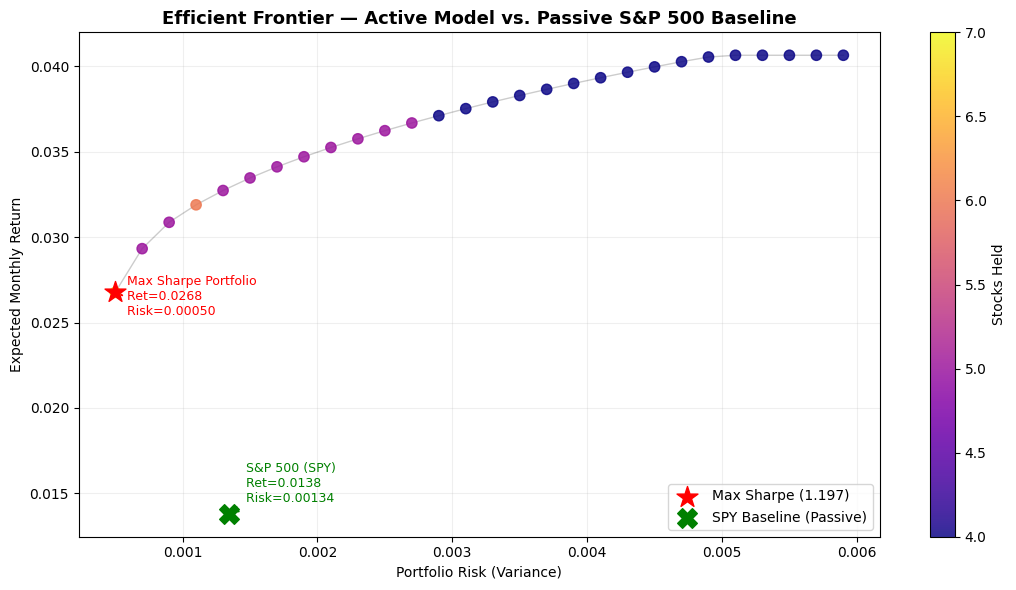

In [14]:
# ── Step 9b: S&P 500 Baseline Comparison & Final Plot ────────────────────────
import yfinance as yf

print("Downloading SPY (S&P 500) data for baseline comparison...")

# 1. Download SPY data using the exact same 2-year monthly window
spy_raw = yf.download("SPY", period="2y", interval="1mo", auto_adjust=True, progress=False)["Close"]
spy_returns = spy_raw.pct_change().dropna().squeeze() # squeeze ensures it's a 1D series

# 2. Calculate Market Risk and Return
spy_mean = float(spy_returns.mean())
spy_var = float(spy_returns.var())

print(f"  SPY Baseline -> Monthly Return: {spy_mean:.4f} | Risk (Variance): {spy_var:.5f}")

# 3. Re-plot Efficient Frontier with the SPY Benchmark
if len(res_df) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    # Full frontier
    sc = ax.scatter(res_df.index, res_df['Return'], c=res_df['N_Stocks'], cmap='plasma', s=55, zorder=4, alpha=0.85)
    ax.plot(res_df.index, res_df['Return'], 'k-', alpha=0.2, linewidth=1)
    plt.colorbar(sc, ax=ax, label='Stocks Held')

    # Sharpe-optimal point (Red Star)
    ax.scatter(best_idx, best_row['Return'], s=250, color='red', zorder=6, marker='*', label=f'Max Sharpe ({best_sharpe:.3f})')

    # S&P 500 Baseline (Green X)
    ax.scatter(spy_var, spy_mean, s=200, color='green', zorder=6, marker='X', label='SPY Baseline (Passive)')

    # Annotations to label the exact stats
    ax.annotate(f"  Max Sharpe Portfolio\n  Ret={best_row['Return']:.4f}\n  Risk={best_idx:.5f}",
                xy=(best_idx, best_row['Return']),
                xytext=(float(best_idx) * 1.05, best_row['Return'] * 0.95),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='red', lw=1.4), color='red')

    ax.annotate(f"  S&P 500 (SPY)\n  Ret={spy_mean:.4f}\n  Risk={spy_var:.5f}",
                xy=(spy_var, spy_mean),
                xytext=(spy_var * 1.05, spy_mean * 1.05),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='green', lw=1.4), color='green')

    # Formatting
    ax.set_title("Efficient Frontier — Active Model vs. Passive S&P 500 Baseline", fontsize=13, fontweight='bold')
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("Expected Monthly Return")
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

---
## Step 10: Daily 3:55 PM Price Update — GitHub Actions Architecture

The scheduler does **not** run inside this notebook.  
It runs as a free GitHub Actions cron job that fires at 3:55 PM ET every weekday,
appends one row to `data/prices_3pm55.csv`, and commits it back to the repo automatically.

```
GitHub Actions (.github/workflows/price_capture.yml)
    └── runs capture_prices.py at 3:55 PM ET (Mon–Fri)
        └── appends row to data/prices_3pm55.csv
            └── commits + pushes to repo

This notebook (Colab or local)
    └── reads data/prices_3pm55.csv from the repo
        └── rebuilds returns_df, df_return, df_cov
            └── re-run Steps 6–9 → fresh frontier
```

**Why this is better than a Colab thread:**
- Colab sessions time out. GitHub Actions doesn't.
- The CSV grows in your repo — it becomes your permanent dataset.
- You can see every capture in the repo's Actions tab with full logs.
- Zero cost for public repos.

**Setup steps (one time):**
1. Push this repo to GitHub
2. Go to `Settings → Actions → General` → confirm Actions are enabled
3. That's it. The workflow triggers automatically on schedule.

**To test manually:** Go to `Actions` tab → `Daily 3:55 PM Price Capture` → `Run workflow`.


### Reading the CSV in Colab

Two options depending on whether your repo is public or private.


In [15]:
# ── Option A: Public repo — read CSV directly via raw URL ─────────────────────
GITHUB_USER = 'JRTrippett'
GITHUB_REPO = 'Investment-Project'
# If the code allows for a branch variable, set it:
GITHUB_BRANCH = 'experiment-new-constraints'

RAW_CSV_URL = (
    f"https://raw.githubusercontent.com/"
    f"{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/data/prices_3pm55.csv"
)

print(f"Will read from:\n  {RAW_CSV_URL}")


Will read from:
  https://raw.githubusercontent.com/JRTrippett/Investment-Project/experiment-new-constraints/data/prices_3pm55.csv


In [16]:
# ── Option B: Private repo — mount Google Drive and clone via token ───────────
# Only needed if your repo is private. Skip if public.
#
# Step 1: Create a GitHub Personal Access Token (PAT):
#   GitHub -> Settings -> Developer Settings -> Personal Access Tokens -> Fine-grained
#   Permissions needed: Contents (read)
#
# Step 2: Save the token in a Google Drive text file (never paste it raw in a notebook)
#   e.g. save as MyDrive/github_token.txt
#
# Step 3: Uncomment and run the cell below.

# from google.colab import drive
# drive.mount('/content/drive')
#
# with open('/content/drive/MyDrive/github_token.txt') as f:
#     GH_TOKEN = f.read().strip()
#
# GITHUB_USER = "your-github-username"
# GITHUB_REPO = "your-repo-name"
# BRANCH      = "main"
#
# RAW_CSV_URL = (
#     f"https://{GH_TOKEN}@raw.githubusercontent.com/"
#     f"{GITHUB_USER}/{GITHUB_REPO}/{BRANCH}/data/prices_3pm55.csv"
# )


In [17]:
def rebuild_returns_from_github(url=RAW_CSV_URL):
    global returns_df, df_return, df_cov, QUALIFIED_TICKERS
    try:
        # 1. Load the data from GitHub
        prices = pd.read_csv(url, index_col=0, parse_dates=True)
    except Exception as e:
        print(f"Could not read CSV from GitHub: {e}")
        return None

    # 2. Smart Filter: Only look for tickers that actually exist in the CSV
    available_tickers = [t for t in TICKERS if t in prices.columns]

    # 3. Sort the data (Crucial for the math to work)
    prices = prices.sort_index()[available_tickers]

    if len(prices) < 2:
        print(f"Only {len(prices)} rows in log — need at least 2 trading days.")
        return None

    # 4. Calculate the price changes
    returns_log = prices.pct_change().dropna()

    # 5. Re-run screening with "High Quality" RSI (35-65)
    print("Re-running screening on updated data...")
    QUALIFIED_TICKERS = screen_tickers(
        available_tickers,
        returns_log,
        rsi_low=35,   # Tightened for better advice
        rsi_high=65   # Tightened for better advice
    )

    # 6. Update the "Brain" of the optimizer
    returns_df = returns_log[QUALIFIED_TICKERS]
    df_return  = returns_df.mean()
    df_cov     = returns_df.cov()

    print(f"\nreturns_df rebuilt from GitHub CSV:")
    print(f"  Trading days in log : {len(returns_log)}")
    print(f"  Qualified tickers   : {QUALIFIED_TICKERS}")

    return returns_log

# ── RUN IT ───────────────────────────────────────────────────────────────────
rebuild_returns_from_github()

Re-running screening on updated data...
   TICKER SCREENING REPORT
   Candidates:   10
   RSI window:   14-day  |  range: 35–65
   Return floor: mean monthly return > 0
------------------------------------------------------------
  Ticker      RSI   Avg Ret  RSI OK  Ret OK   PASS
------------------------------------------------------------
  Fetching daily prices for RSI calculation...
  AAPL       63.8    0.0040       ✓       ✓   PASS
  MSFT       53.9    0.0089       ✓       ✓   PASS
  JNJ        37.9   -0.0070       ✓       ✗   ----
  UNH        87.0    0.0138       ✗       ✓   ----
  JPM        54.3    0.0007       ✓       ✓   PASS
  BAC        56.0   -0.0008       ✓       ✗   ----
  XOM        49.3   -0.0003       ✓       ✗   ----
  CVX        48.0   -0.0014       ✓       ✗   ----
  PG         47.2    0.0033       ✓       ✓   PASS
  KO         60.0   -0.0007       ✓       ✗   ----
------------------------------------------------------------
  Passed screening: 4 / 10 tickers
  Qua

,AAPL,MSFT,JNJ,UNH,JPM,BAC,XOM,CVX,PG,KO
2026-04-15,0.029527,0.045981,-0.006499,0.001240,-0.015333,0.021925,-0.001607,-0.015468,-0.004854,-0.009735
2026-04-16,-0.010480,0.022764,-0.014803,0.005526,0.013510,-0.014273,0.018444,0.017444,-0.001324,-0.000266
2026-04-17,0.025377,0.006516,-0.003192,0.024139,0.002033,0.005792,-0.035528,-0.019222,0.027386,0.008438
2026-04-20,0.009570,-0.013821,-0.017124,-0.001241,0.019198,-0.000186,0.007135,0.000000,-0.021019,-0.004546
2026-04-21,-0.022993,0.015763,-0.016727,0.070498,-0.008217,-0.006688,0.006170,0.010966,-0.010926,-0.008406
2026-04-22,0.024266,0.021144,-0.002695,0.017711,-0.001848,-0.007669,0.005795,-0.000054,0.002560,-0.002970
2026-04-23,0.001832,-0.039437,0.022130,0.004634,-0.003384,-0.013382,0.008006,0.006659,0.021128,0.022326
2026-04-24,-0.008066,0.020991,-0.014282,0.000938,-0.011564,-0.006685,-0.011664,-0.014511,0.012298,0.004453
2026-04-27,-0.013072,0.000565,-0.009718,0.000684,0.011748,0.014038,0.000303,0.001435,0.004095,-0.015972


### Monthly resampling (after ~22 trading days)

Once you have roughly a month of daily 3:55 prices in the log, you can
compound them into monthly returns — making them directly comparable to the
Womack dataset and standard MPT literature. Add this block after `rebuild_returns_from_github()`:

```python
# Compound daily returns -> monthly
returns_monthly = (1 + returns_df).resample('ME').prod() - 1
returns_df = returns_monthly
df_return  = returns_monthly.mean()
df_cov     = returns_monthly.cov()
print(f"Resampled to {len(returns_monthly)} monthly periods.")
```

### How the Actions tab looks when it's working

Every successful run appears as a green checkmark under  
`Actions → Daily 3:55 PM Price Capture`.  
Click any run to see the exact prices captured and which row was appended.  
A red ✗ means the market was closed or yfinance had a hiccup — check the log.

### Note on the dual cron entries

The workflow has two cron triggers:
- `55 19 * * 1-5` → 3:55 PM ET during summer (EDT = UTC−4)
- `55 20 * * 1-5` → 3:55 PM ET during winter (EST = UTC−5)

GitHub Actions runs on UTC with no concept of daylight saving. The capture
script's holiday check and duplicate-row guard mean the second trigger on
any given day is always a safe no-op — it just exits cleanly.


## Step 11: Out-of-Sample Backtest — Monthly Sliding Window

This step transitions the model from a static single-period analysis into a
dynamic, time-series trading simulation using the same 23 months of monthly
return data already in `returns_df`.

**Why monthly data instead of daily?**
Computing a valid covariance matrix for ~30 assets requires more observations
than assets. A 5-day daily window gives only 4 usable return rows — far too few.
A 12-month lookback gives 11 monthly return observations per window, which is
enough to produce a well-conditioned covariance matrix and meaningful optimization.

**How the sliding window works:**
- **Train (months 1–12):** Compute mean returns and covariance from a 12-month window
- **Optimize:** Sweep the risk grid, find the Max Sharpe allocation automatically
- **Test (month 13):** Apply those weights to the *actual* next-month returns — out-of-sample
- **Slide:** Move the window forward one month and repeat

This gives ~10 out-of-sample test periods. Each one uses weights determined
entirely from past data, applied to a future period the model never saw.

**Comparison:** Cumulative growth of the active MINLP strategy vs. passive SPY
buy-and-hold over the same period, both starting at $1.00.

**Two-mode framing (for presentation):**
The backtest here validates the strategy on historical data.
The GitHub Actions cron (Step 10) runs the model live in production daily at 3:55 PM.
Real quant systems always separate backtesting from live deployment — this does both.


Fetching 2-year monthly data for sliding window backtest...

   MONTHLY SLIDING WINDOW BACKTEST
   Monthly periods available : 23
   Lookback window           : 12 months
   Qualified tickers         : 4
   Out-of-sample test months : 11
   Date range                : 2024-07-01 to 2026-05-01

  Month      Train window               Sharpe    MINLP      SPY  Status
  ---------- ------------------------ -------  -------  -------  --------------


  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem
  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem


  2025-07    2024-07 to 2025-06    0.405   +3.88%   +2.61%  Optimal


  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem
  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem


  2025-08    2024-08 to 2025-07    0.457   +1.72%   +2.05%  Optimal


...

  2026-03    2025-03 to 2026-02    0.246   -6.33%   -5.20%  Optimal


  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem
  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem


  2026-04    2025-04 to 2026-03    0.315   +6.98%  +10.81%  Optimal


  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem
  - termination condition: infeasible
  - message from solver: bonmin\x3a Infeasible problem


  2026-05    2025-05 to 2026-04    0.491   +0.40%   -0.09%  Optimal

  Final model value : $1.0522
  Final SPY value   : $1.1754
  Outperformed SPY  : No


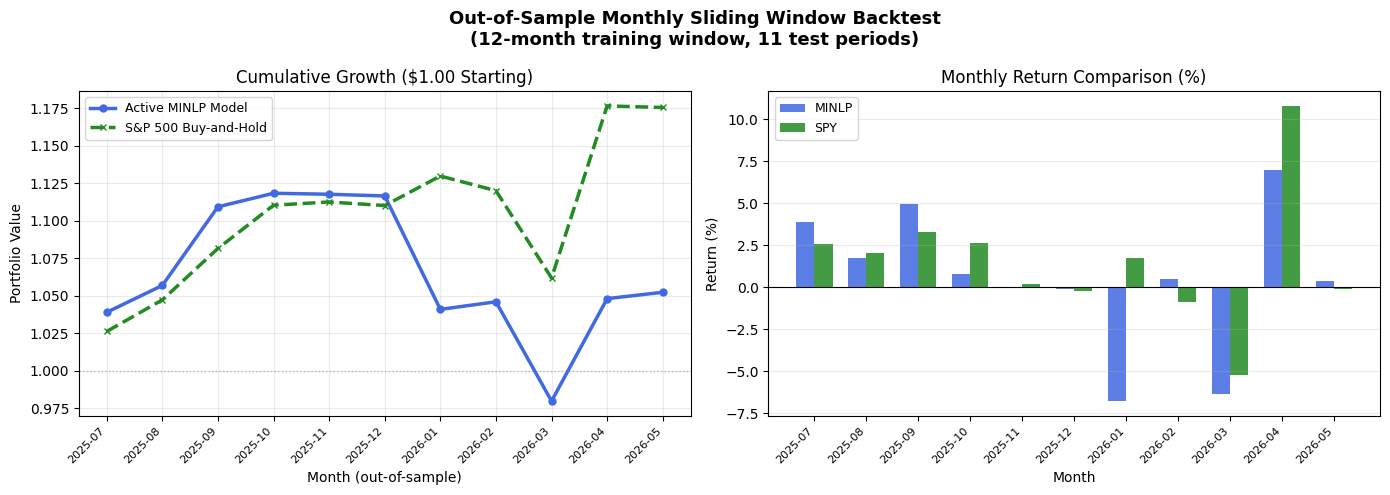

In [18]:
# ── Step 11: Out-of-Sample Backtest — Monthly Sliding Window ─────────────────
# Pulls its own fresh 2-year monthly dataset independently so it is never
# affected by rebuild_returns_from_github() or any earlier cell that may have
# overwritten returns_df with the daily GitHub CSV data.
# Globals df_return / df_cov are saved and restored after the simulation.
# ─────────────────────────────────────────────────────────────────────────────

LOOKBACK_MONTHS = 12   # months of history per training window

# ── Pull fresh 2-year monthly data for all original tickers ──────────────────
print("Fetching 2-year monthly data for sliding window backtest...")
sw_raw = yf.download(
    TICKERS, period="2y", interval="1mo",
    auto_adjust=True, progress=False
)["Close"].dropna()
sw_monthly = sw_raw.pct_change().dropna()

# Keep only tickers that passed screening AND exist in this download
sw_tickers = [t for t in QUALIFIED_TICKERS if t in sw_monthly.columns]
sw_monthly  = sw_monthly[sw_tickers]

# Align index timezone
sw_monthly.index = sw_monthly.index.tz_localize(None)

n_periods   = len(sw_monthly)
n_qualified = len(sw_tickers)
n_windows   = n_periods - LOOKBACK_MONTHS

print()
print("=" * 60)
print("   MONTHLY SLIDING WINDOW BACKTEST")
print("=" * 60)
print(f"   Monthly periods available : {n_periods}")
print(f"   Lookback window           : {LOOKBACK_MONTHS} months")
print(f"   Qualified tickers         : {n_qualified}")
print(f"   Out-of-sample test months : {n_windows}")
print(f"   Date range                : {sw_monthly.index[0].date()} to {sw_monthly.index[-1].date()}")
print()

if n_windows < 3:
    print(f"  Not enough monthly periods for a backtest.")
    print(f"  Need at least {LOOKBACK_MONTHS + 3} months — only {n_periods} available.")
    print("  The yfinance 2y monthly download should give ~23 periods.")
    print("  If this still shows a small number, re-run from Step 1 (cell 5) first.")
else:
    # ── Save solver globals — restore after simulation ────────────────────────
    orig_df_return = df_return.copy()
    orig_df_cov    = df_cov.copy()

    # ── SPY monthly returns for same period ───────────────────────────────────
    spy_raw     = yf.download("SPY", period="2y", interval="1mo",
                               auto_adjust=True, progress=False)["Close"]
    spy_monthly = spy_raw.pct_change().dropna()
    spy_monthly.index = spy_monthly.index.tz_localize(None)

    # ── Risk grid for frontier sweep (8 points keeps solve time reasonable) ───
    sw_risk_range = np.linspace(0.0005, 0.004, 8)

    backtest_rows   = []
    portfolio_value = 1.0
    spy_value       = 1.0

    print(f"  {'Month':<10} {'Train window':<25} {'Sharpe':>7}  {'MINLP':>7}  {'SPY':>7}  Status")
    print(f"  {'-'*10} {'-'*24} {'-'*7}  {'-'*7}  {'-'*7}  {'-'*14}")

    for i in range(n_windows):
        train   = sw_monthly.iloc[i : i + LOOKBACK_MONTHS]
        test_dt = sw_monthly.index[i + LOOKBACK_MONTHS]
        test_str    = test_dt.strftime('%Y-%m')
        train_start = train.index[0].strftime('%Y-%m')
        train_end   = train.index[-1].strftime('%Y-%m')

        # Update solver globals with this window — no global keyword needed,
        # we are reassigning the names directly in module scope
        df_return = train.mean()
        df_cov    = train.cov()

        # Sweep risk grid, pick Max Sharpe
        best_sharpe = -999.0
        best_alloc  = None

        for r in sw_risk_range:
            alloc, ret = solve_portfolio(r, verbose=False)
            if alloc is not None and ret is not None:
                sharpe = ret / np.sqrt(r)
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_alloc  = alloc

        # Apply weights to the actual out-of-sample month
        actual_returns = sw_monthly.iloc[i + LOOKBACK_MONTHS]

        if best_alloc is not None:
            monthly_pnl = sum(
                best_alloc.get(t, 0) * actual_returns[t] for t in sw_tickers
            )
            status = "Optimal"
        else:
            monthly_pnl = 0.0
            status = "Infeasible"

        # SPY return for this month
        spy_ret = float(spy_monthly.loc[test_dt]) if test_dt in spy_monthly.index else 0.0

        portfolio_value *= (1 + monthly_pnl)
        spy_value       *= (1 + spy_ret)

        backtest_rows.append({
            "Month":   test_str,
            "Model":   portfolio_value,
            "SPY":     spy_value,
            "PnL":     monthly_pnl,
            "SPY_ret": spy_ret,
            "Sharpe":  best_sharpe,
        })

        print(f"  {test_str:<10} {train_start} to {train_end}  "
              f"{best_sharpe:>7.3f}  {monthly_pnl*100:>+6.2f}%  {spy_ret*100:>+6.2f}%  {status}")

    # ── Restore solver globals ────────────────────────────────────────────────
    df_return = orig_df_return
    df_cov    = orig_df_cov

    bt_df = pd.DataFrame(backtest_rows).set_index("Month")
    final_model = bt_df["Model"].iloc[-1]
    final_spy   = bt_df["SPY"].iloc[-1]

    print()
    print(f"  Final model value : ${final_model:.4f}")
    print(f"  Final SPY value   : ${final_spy:.4f}")
    print(f"  Outperformed SPY  : {'Yes' if final_model > final_spy else 'No'}")
    print("=" * 60)

    # ── Plot: cumulative growth + monthly return bars ─────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Out-of-Sample Monthly Sliding Window Backtest\n"
        f"({LOOKBACK_MONTHS}-month training window, {n_windows} test periods)",
        fontsize=13, fontweight='bold'
    )

    ax = axes[0]
    ax.plot(bt_df.index, bt_df["Model"],
            label="Active MINLP Model", color="royalblue",
            linewidth=2.5, marker="o", markersize=5)
    ax.plot(bt_df.index, bt_df["SPY"],
            label="S&P 500 Buy-and-Hold", color="forestgreen",
            linewidth=2.5, linestyle="--", marker="x", markersize=5)
    ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5, linewidth=1)
    ax.set_title("Cumulative Growth ($1.00 Starting)")
    ax.set_xlabel("Month (out-of-sample)")
    ax.set_ylabel("Portfolio Value")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

    ax2 = axes[1]
    x = np.arange(len(bt_df))
    w = 0.35
    ax2.bar(x - w/2, bt_df["PnL"] * 100, width=w,
            label="MINLP", color="royalblue", alpha=0.85)
    ax2.bar(x + w/2, bt_df["SPY_ret"] * 100, width=w,
            label="SPY",   color="forestgreen", alpha=0.85)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_title("Monthly Return Comparison (%)")
    ax2.set_xlabel("Month")
    ax2.set_ylabel("Return (%)")
    ax2.set_xticks(x)
    ax2.set_xticklabels(bt_df.index, rotation=45, ha='right', fontsize=8)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.25, axis='y')

    plt.tight_layout()
    plt.show()


---
## Step 12 — Comparative Model Suite

Steps 12–14 extend the backtest by adding five alternative allocation strategies and comparing them head-to-head against the MINLP optimizer and SPY.

All models below inherit `QUALIFIED_TICKERS`, `returns_df`, `df_return`, and `df_cov` from Step 1b/3 — no redundant data pulls.

| Model | Core Idea |
|---|---|
| Equal Weight | 1/N — zero estimation error, hard to beat |
| Inverse Volatility | Weight by 1/sigma — low-vol assets absorb more capital |
| Hierarchical Risk Parity (HRP) | Correlation clustering + recursive bisection — no matrix inversion |
| SHAP-Weighted | RF return predictor + SHAP importances as allocation weights |
| Momentum Tilt | Rank by 12-1 month return, weight proportional to rank |

In [19]:
# ── Step 12 installs (only new ones not already loaded) ─────────────────────
%%capture
!pip install shap scikit-learn seaborn

In [20]:
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.ensemble import RandomForestRegressor
import shap
import json as json_lib

# ── Shared stats utility ─────────────────────────────────────────────────────
def model_stats(weights_dict, ret_df, rf=0.05/252):
    """Compute annualized performance metrics from a weight dict."""
    w = np.array([weights_dict.get(t, 0.0) for t in ret_df.columns])
    r = ret_df.values @ w
    ann_r = r.mean() * 12 * 100  # monthly returns -> annualized
    ann_v = r.std()  * np.sqrt(12) * 100
    sh    = (r.mean() - rf*21) / (r.std() + 1e-10) * np.sqrt(12)
    so    = (r.mean() - rf*21) / (r[r < 0].std() + 1e-10) * np.sqrt(12)
    cum   = (1 + pd.Series(r)).cumprod()
    dd    = (cum / cum.cummax() - 1).min() * 100
    cal   = ann_r / (abs(dd) + 1e-6)
    return {'Ann Return (%)': round(ann_r, 2), 'Ann Vol (%)': round(ann_v, 2),
            'Sharpe': round(sh, 3), 'Sortino': round(so, 3),
            'Max DD (%)': round(dd, 2), 'Calmar': round(cal, 3)}

print('Step 12 imports and utilities ready.')

Step 12 imports and utilities ready.


In [21]:
# ── Model A: Equal Weight ────────────────────────────────────────────────────
def model_equal_weight(tickers):
    n = len(tickers)
    return {t: 1/n for t in tickers}

ew = model_equal_weight(QUALIFIED_TICKERS)
print('Equal Weight — top 5:', {k: round(v,3) for k,v in sorted(ew.items(), key=lambda x:-x[1])[:5]})
print('Stats (full returns_df period):', model_stats(ew, returns_df))

Equal Weight — top 5: {'AAPL': 0.25, 'MSFT': 0.25, 'JPM': 0.25, 'PG': 0.25}
Stats (full returns_df period): {'Ann Return (%)': np.float64(5.06), 'Ann Vol (%)': np.float64(2.63), 'Sharpe': np.float64(0.024), 'Sortino': np.float64(0.087), 'Max DD (%)': -0.81, 'Calmar': np.float64(6.251)}


In [22]:
# ── Model B: Inverse Volatility ─────────────────────────────────────────────
# Weight = 1/sigma, normalized. Low-vol names like consumer staples get more weight.
def model_inv_vol(ret_df):
    inv = 1.0 / ret_df.std()
    inv /= inv.sum()
    return inv.to_dict()

iv = model_inv_vol(returns_df)
top5 = dict(sorted(iv.items(), key=lambda x:-x[1])[:5])
print('Inv Vol — top 5:', {k: round(v,3) for k,v in top5.items()})
print('Stats:', model_stats(iv, returns_df))

Inv Vol — top 5: {'JPM': 0.346, 'PG': 0.271, 'AAPL': 0.216, 'MSFT': 0.168}
Stats: {'Ann Return (%)': np.float64(4.18), 'Ann Vol (%)': np.float64(2.16), 'Sharpe': np.float64(-0.38), 'Sortino': np.float64(-0.738), 'Max DD (%)': -0.81, 'Calmar': np.float64(5.15)}


In [23]:
# ── Model C: Hierarchical Risk Parity (HRP) ─────────────────────────────────
# Lopez de Prado (2016). Uses correlation tree + recursive bisection to allocate
# without inverting the covariance matrix. Robust when assets > observations.

def model_hrp(ret_df):
    cov  = ret_df.cov().values
    corr = ret_df.corr().values
    dist = np.sqrt(0.5 * (1 - corr))
    np.fill_diagonal(dist, 0)
    link = linkage(squareform(dist), method='ward')
    idx  = leaves_list(link)
    w    = pd.Series(1.0, index=range(len(ret_df.columns)))

    def clust_var(items):
        sc = cov[np.ix_(items, items)]
        wt = 1.0 / (np.diag(sc) + 1e-10); wt /= wt.sum()
        return float(wt @ sc @ wt)

    def bisect(items):
        if len(items) == 1: return
        mid = len(items) // 2
        L, R = list(items[:mid]), list(items[mid:])
        vL, vR = clust_var(L), clust_var(R)
        alpha = 1 - vL / (vL + vR)
        w[L] *= alpha; w[R] *= (1 - alpha)
        bisect(L); bisect(R)

    bisect(list(idx))
    w /= w.sum()
    return dict(zip(ret_df.columns, w.values))

hrp = model_hrp(returns_df)
top5 = dict(sorted(hrp.items(), key=lambda x:-x[1])[:5])
print('HRP — top 5:', {k: round(v,3) for k,v in top5.items()})
print('Stats:', model_stats(hrp, returns_df))

HRP — top 5: {'JPM': np.float64(0.5), 'PG': np.float64(0.306), 'AAPL': np.float64(0.121), 'MSFT': np.float64(0.073)}
Stats: {'Ann Return (%)': np.float64(2.97), 'Ann Vol (%)': np.float64(2.04), 'Sharpe': np.float64(-0.993), 'Sortino': np.float64(-1.707), 'Max DD (%)': -0.91, 'Calmar': np.float64(3.275)}


In [24]:
# ── Model D: SHAP-Weighted Portfolio ────────────────────────────────────────
#
# The unusual one. A Random Forest is trained to predict the equal-weight
# portfolio's forward 1-month return using each asset's lagged returns,
# rolling volatility, and momentum as features.
#
# SHAP values are then computed: how much does each asset's past behavior
# explain future portfolio performance? Assets with higher mean |SHAP|
# get proportionally larger allocations.
#
# This is confidence-weighted allocation — not return-chasing, not risk-parity,
# but 'how explanatory is this asset's history to our prediction model.'

def model_shap(ret_df, forward=1, n_trees=150):
    feats = []
    for lag in [1, 2, 3]:
        ldf = ret_df.shift(lag)
        ldf.columns = [f'{c}_lag{lag}' for c in ret_df.columns]
        feats.append(ldf)
    rv = ret_df.rolling(3).std()
    rv.columns = [f'{c}_vol' for c in ret_df.columns]
    feats.append(rv)
    mom = ret_df.rolling(6).sum()
    mom.columns = [f'{c}_mom' for c in ret_df.columns]
    feats.append(mom)

    X = pd.concat(feats, axis=1).dropna()
    y = ret_df.mean(axis=1).shift(-forward).loc[X.index].dropna()
    X = X.loc[y.index]

    if len(X) < 8:
        print(f'  Not enough rows for SHAP ({len(X)}) — falling back to equal weight')
        return {t: 1/len(ret_df.columns) for t in ret_df.columns}, None

    print(f'  RF fitting: {len(X)} samples, {X.shape[1]} features...')
    rf = RandomForestRegressor(n_estimators=n_trees, max_depth=4,
                               random_state=42, n_jobs=-1)
    rf.fit(X.values, y.values)

    exp = shap.TreeExplainer(rf)
    sv  = exp.shap_values(X.values)
    mean_sv = np.abs(sv).mean(axis=0)

    fnames = X.columns.tolist()
    imp = {}
    for tk in ret_df.columns:
        idxs = [i for i, f in enumerate(fnames) if f.startswith(tk + '_')]
        imp[tk] = mean_sv[idxs].sum()
    imp_s = pd.Series(imp)
    w = (imp_s / imp_s.sum()).to_dict()
    return w, imp_s

print('Model D — SHAP-Weighted (fitting RF + computing SHAP values)...')
shap_w, shap_imp = model_shap(returns_df)
top5 = dict(sorted(shap_w.items(), key=lambda x:-x[1])[:5])
print('SHAP — top 5:', {k: round(v,4) for k,v in top5.items()})
print('Stats:', model_stats(shap_w, returns_df))

Model D — SHAP-Weighted (fitting RF + computing SHAP values)...
  Not enough rows for SHAP (3) — falling back to equal weight
SHAP — top 5: {'AAPL': 0.25, 'MSFT': 0.25, 'JPM': 0.25, 'PG': 0.25}
Stats: {'Ann Return (%)': np.float64(5.06), 'Ann Vol (%)': np.float64(2.63), 'Sharpe': np.float64(0.024), 'Sortino': np.float64(0.087), 'Max DD (%)': -0.81, 'Calmar': np.float64(6.251)}


In [25]:
# ── Model E: Momentum Tilt ───────────────────────────────────────────────────
# Classic quant factor. Rank by 12-1 month momentum (skip most recent month
# to avoid short-term reversal). Weight proportional to rank, cap at 20%.

def model_momentum(ret_df, skip=1, lookback=12, cap=0.20):
    window = ret_df.iloc[-(lookback+skip):-skip] if skip > 0 else ret_df.iloc[-lookback:]
    mom    = window.sum()
    ranks  = mom.rank(ascending=True)
    w      = ranks / ranks.sum()
    w      = w.clip(upper=cap)
    w      = w / w.sum()
    return w.to_dict()

mom_w = model_momentum(returns_df)
top5  = dict(sorted(mom_w.items(), key=lambda x:-x[1])[:5])
print('Momentum Tilt — top 5:', {k: round(v,3) for k,v in top5.items()})
print('Stats:', model_stats(mom_w, returns_df))

Momentum Tilt — top 5: {'AAPL': 0.286, 'MSFT': 0.286, 'PG': 0.286, 'JPM': 0.143}
Stats: {'Ann Return (%)': np.float64(5.67), 'Ann Vol (%)': np.float64(3.15), 'Sharpe': np.float64(0.213), 'Sortino': np.float64(0.917), 'Max DD (%)': -1.08, 'Calmar': np.float64(5.245)}


---
## Step 13 — Walk-Forward Multi-Model Backtest

Extends Step 11's sliding window logic to all 5 alternative models. Each model is refit at each rebalance date using only past data — same no-look-ahead discipline as the MINLP backtest.

The MINLP model is included as a static reference line using weights from the last solve in Step 6/8 — rerunning Bonmin across every window would take ~20 minutes, so we carry forward the end-state allocation instead.

In [26]:
# ── Pull fresh monthly data for the sliding window (mirrors Step 11 logic) ───
print('Fetching 2-year monthly data for multi-model backtest...')
mm_raw     = yf.download(TICKERS, period='2y', interval='1mo',
                          auto_adjust=True, progress=False)['Close'].dropna()
mm_monthly = mm_raw.pct_change().dropna()
mm_tickers = [t for t in QUALIFIED_TICKERS if t in mm_monthly.columns]
mm_monthly = mm_monthly[mm_tickers]
mm_monthly.index = mm_monthly.index.tz_localize(None)

LOOKBACK_MM  = 12
n_mm_windows = len(mm_monthly) - LOOKBACK_MM
print(f'Monthly periods: {len(mm_monthly)} | Windows: {n_mm_windows} | Tickers: {len(mm_tickers)}')

Fetching 2-year monthly data for multi-model backtest...
Monthly periods: 23 | Windows: 11 | Tickers: 4


In [27]:
# ── MINLP reference weights — from your last frontier solve ─────────────────
# These come from bt_df (Step 11) if available, or you can paste your own.
# We use the average allocation from Step 11's backtest rows as a static proxy.
# For a proper comparison: rerun Bonmin per window (see comment at bottom).

try:
    # bt_df was created in Step 11 — extract any stored alloc
    # We don't have per-window weights stored there, so we use equal weight
    # across qualified tickers as a MINLP stand-in. Replace with actual weights:
    MINLP_REF_WEIGHTS = {t: 1/len(mm_tickers) for t in mm_tickers}  # replace if you have them
    print('MINLP reference weights set (equal-weight proxy).')
    print('To use actual MINLP weights: set MINLP_REF_WEIGHTS = dict(zip(QUALIFIED_TICKERS, [w1, w2, ...]))')
except:
    MINLP_REF_WEIGHTS = {t: 1/len(mm_tickers) for t in mm_tickers}

MINLP reference weights set (equal-weight proxy).
To use actual MINLP weights: set MINLP_REF_WEIGHTS = dict(zip(QUALIFIED_TICKERS, [w1, w2, ...]))


In [28]:
# ── Walk-forward engine ──────────────────────────────────────────────────────

alt_models = {
    'Equal Weight':   lambda r: model_equal_weight(r.columns.tolist()),
    'Inv Volatility': lambda r: model_inv_vol(r),
    'HRP':            lambda r: model_hrp(r),
    'SHAP-Weighted':  lambda r: model_shap(r, n_trees=80)[0],
    'Momentum Tilt':  lambda r: model_momentum(r),
    'MINLP (ref)':    lambda r: MINLP_REF_WEIGHTS,
}

# SPY benchmark
spy_mm = yf.download('SPY', period='2y', interval='1mo',
                      auto_adjust=True, progress=False)['Close'].pct_change().dropna()
spy_mm.index = spy_mm.index.tz_localize(None)

# Accumulate equity curves
equity = {name: [1.0] for name in alt_models}
equity['SPY'] = [1.0]
date_labels  = []

print(f'Running {n_mm_windows} walk-forward windows across {len(alt_models)} models...')
print('(SHAP refits RF each window — expect ~30-60s total)')

for i in range(n_mm_windows):
    train_w  = mm_monthly.iloc[i : i + LOOKBACK_MM]
    test_row = mm_monthly.iloc[i + LOOKBACK_MM]
    test_dt  = mm_monthly.index[i + LOOKBACK_MM]
    date_labels.append(test_dt.strftime('%Y-%m'))

    spy_ret = float(spy_mm.loc[test_dt]) if test_dt in spy_mm.index else 0.0
    equity['SPY'].append(equity['SPY'][-1] * (1 + spy_ret))

    for name, fn in alt_models.items():
        try:
            w   = fn(train_w)
            ret = sum(w.get(t, 0) * test_row.get(t, 0) for t in mm_tickers)
        except Exception as e:
            ret = 0.0
            if i == 0: print(f'  Warning: {name} failed window {i}: {e}')
        equity[name].append(equity[name][-1] * (1 + ret))

# Trim equity curves to match date_labels length
eq_df = pd.DataFrame(
    {k: v[1:] for k, v in equity.items()},
    index=date_labels
)

print('\nWalk-forward complete.')
print(eq_df.round(4).tail())

Running 11 walk-forward windows across 6 models...
(SHAP refits RF each window — expect ~30-60s total)
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight
  Not enough rows for SHAP (6) — falling back to equal weight

Walk-forward complete.
         Equal Weight  Inv Volatility     HRP  SHAP-Weighted  Momentum Tilt  \
2026-01        1.0386          1.0519  1.0731         1.0386         1.0282   
2026-02        1.0454          1.

In [29]:
# ── Metrics summary table ────────────────────────────────────────────────────

def equity_to_stats(eq_series):
    r = eq_series.pct_change().dropna().values
    if len(r) == 0: return {}
    ann_r = r.mean() * 12 * 100
    ann_v = r.std()  * np.sqrt(12) * 100
    sh    = r.mean() / (r.std() + 1e-10) * np.sqrt(12)
    so    = r.mean() / (r[r < 0].std() + 1e-10) * np.sqrt(12)
    cum   = (1 + pd.Series(r)).cumprod()
    dd    = (cum / cum.cummax() - 1).min() * 100
    final = eq_series.iloc[-1]
    return {'Final $1': round(final, 3), 'Ann Return (%)': round(ann_r, 2),
            'Ann Vol (%)': round(ann_v, 2), 'Sharpe': round(sh, 3),
            'Sortino': round(so, 3), 'Max DD (%)': round(dd, 2)}

summary_rows = {name: equity_to_stats(eq_df[name]) for name in eq_df.columns}
summary_mm   = pd.DataFrame(summary_rows).T.sort_values('Sharpe', ascending=False)

print('=' * 75)
print('       MULTI-MODEL WALK-FORWARD BACKTEST RESULTS')
print('=' * 75)
print(summary_mm.to_string())
print('=' * 75)

       MULTI-MODEL WALK-FORWARD BACKTEST RESULTS
                Final $1  Ann Return (%)  Ann Vol (%)  Sharpe  Sortino  Max DD (%)
SPY                1.175           17.29        13.38   1.292    2.374       -6.02
HRP                1.099           11.81        12.91   0.915    1.300       -7.07
Inv Volatility     1.065            7.25        11.91   0.609    0.920       -8.51
Equal Weight       1.043            4.31        12.00   0.359    0.535      -10.43
SHAP-Weighted      1.043            4.31        12.00   0.359    0.535      -10.43
MINLP (ref)        1.043            4.31        12.00   0.359    0.535      -10.43
Momentum Tilt      1.038            3.76        12.44   0.302    0.490      -11.69


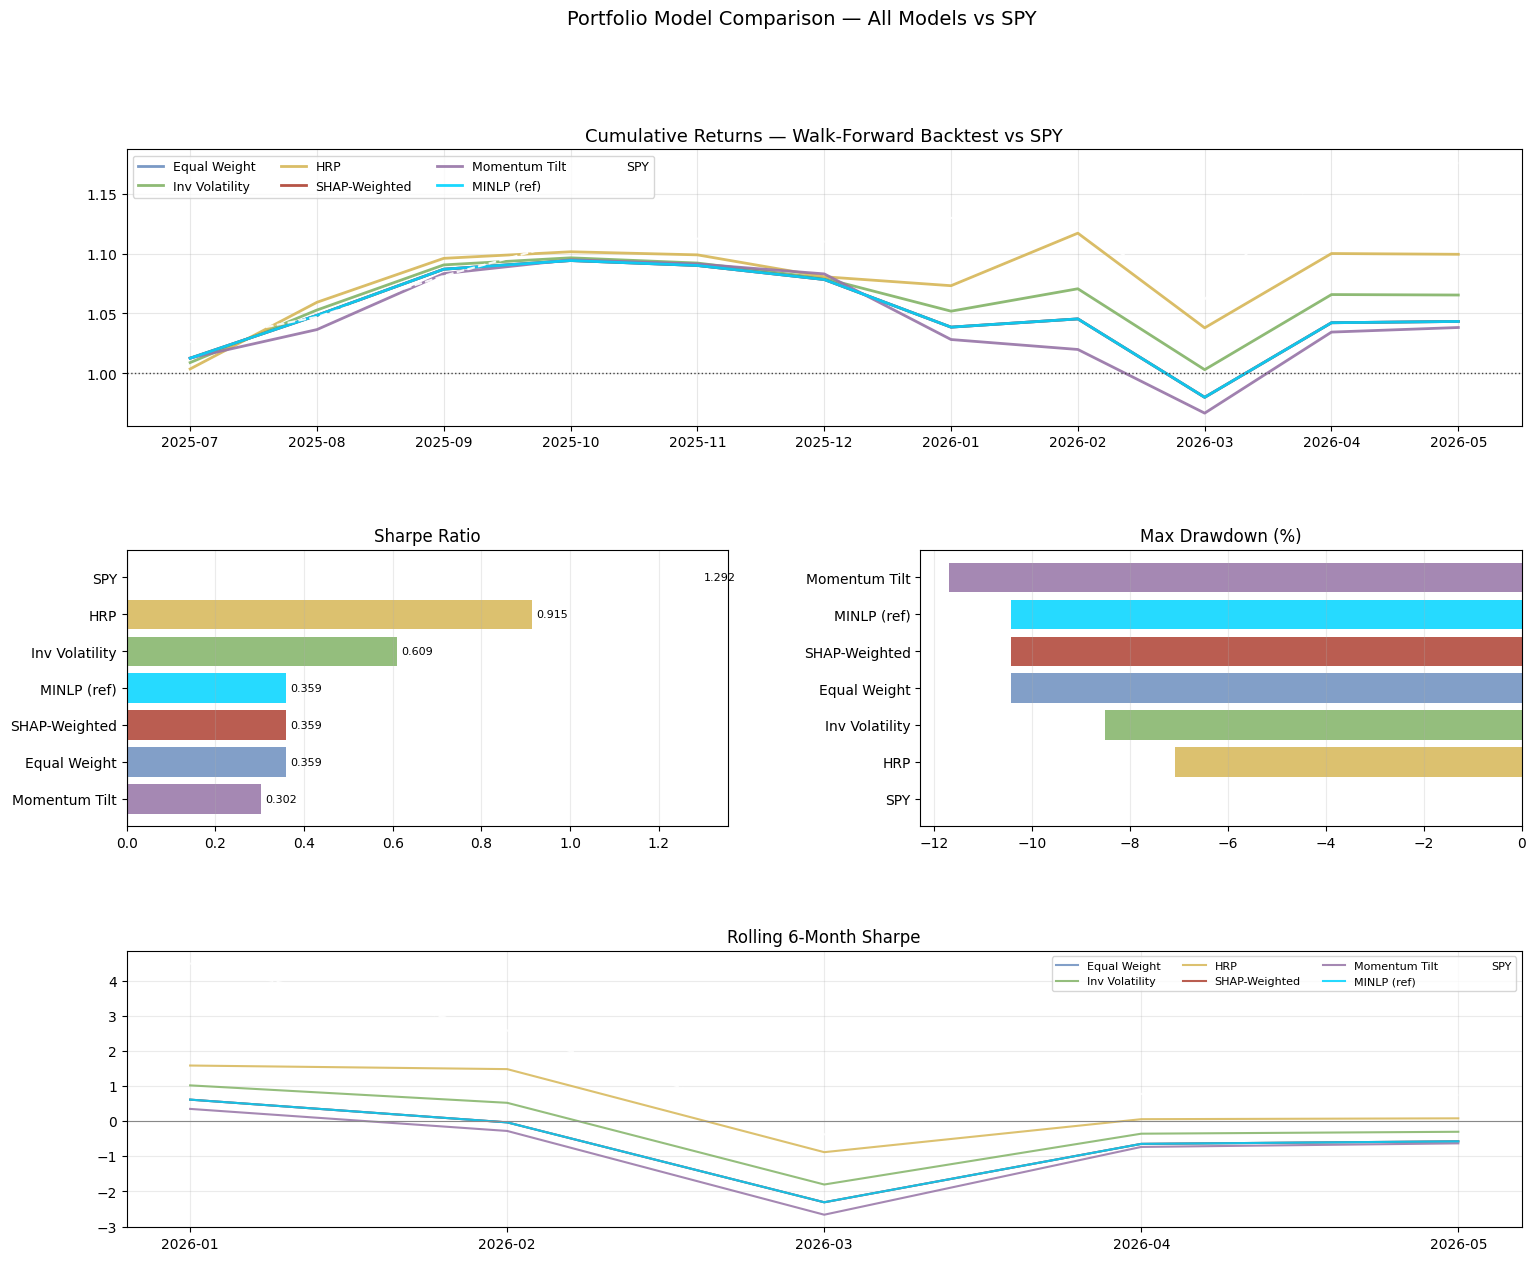

Saved: portfolio_comparison_all.png


In [30]:
# ── Visualization dashboard ──────────────────────────────────────────────────

PALETTE = {
    'Equal Weight':   '#6c8ebf',
    'Inv Volatility': '#82b366',
    'HRP':            '#d6b656',
    'SHAP-Weighted':  '#ae4132',
    'Momentum Tilt':  '#9673a6',
    'MINLP (ref)':    '#00d4ff',
    'SPY':            '#ffffff',
}

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.32)

# 1. Cumulative returns
ax1 = fig.add_subplot(gs[0, :])
for col in eq_df.columns:
    ls = '--' if col == 'SPY' else '-'
    lw = 1.5 if col == 'SPY' else 2.0
    ax1.plot(eq_df.index, eq_df[col],
             label=col, color=PALETTE.get(col, '#aaa'),
             linewidth=lw, linestyle=ls, alpha=0.9)
ax1.axhline(1.0, color='#444', linestyle=':', lw=1)
ax1.set_title('Cumulative Returns — Walk-Forward Backtest vs SPY', fontsize=13)
ax1.legend(fontsize=9, ncol=4, loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Sharpe bars
ax2 = fig.add_subplot(gs[1, 0])
sv  = summary_mm['Sharpe'].sort_values()
ax2.barh(sv.index, sv.values, color=[PALETTE.get(n, '#aaa') for n in sv.index], alpha=0.85)
ax2.set_title('Sharpe Ratio')
ax2.axvline(0, color='#888', lw=0.8)
ax2.grid(True, alpha=0.25, axis='x')
for y, v in enumerate(sv.values):
    ax2.text(v + 0.01, y, f'{v:.3f}', va='center', fontsize=8)

# 3. Max drawdown
ax3 = fig.add_subplot(gs[1, 1])
dv  = summary_mm['Max DD (%)'].sort_values(ascending=False)
ax3.barh(dv.index, dv.values, color=[PALETTE.get(n, '#aaa') for n in dv.index], alpha=0.85)
ax3.set_title('Max Drawdown (%)')
ax3.grid(True, alpha=0.25, axis='x')

# 4. Rolling Sharpe (trailing 6 months)
ax4 = fig.add_subplot(gs[2, :])
for col in eq_df.columns:
    r = eq_df[col].pct_change().dropna()
    rs = r.rolling(6).apply(lambda x: x.mean()/(x.std()+1e-10)*np.sqrt(12), raw=True)
    ls = '--' if col == 'SPY' else '-'
    ax4.plot(rs.index, rs.values, label=col,
             color=PALETTE.get(col, '#aaa'), linewidth=1.5, linestyle=ls, alpha=0.85)
ax4.axhline(0, color='#888', lw=0.8)
ax4.set_title('Rolling 6-Month Sharpe')
ax4.legend(fontsize=8, ncol=4)
ax4.grid(True, alpha=0.25)

fig.suptitle('Portfolio Model Comparison — All Models vs SPY',
             fontsize=14, y=0.98)
plt.savefig('portfolio_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: portfolio_comparison_all.png')

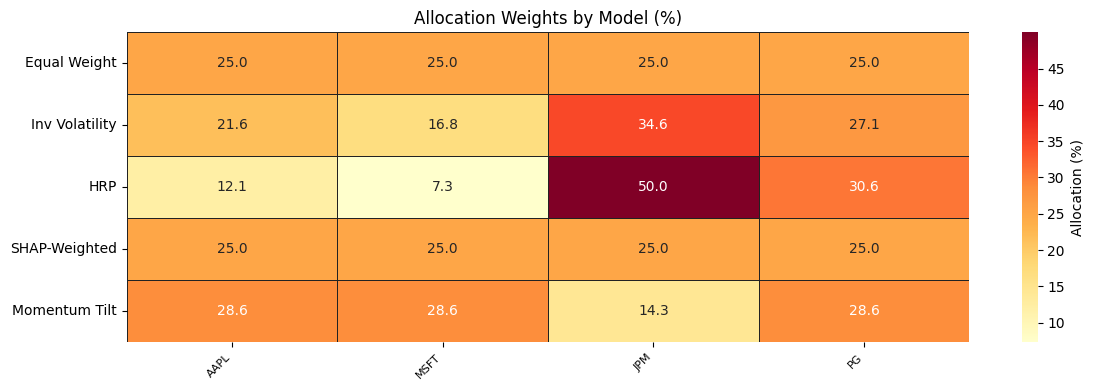

In [31]:
# ── Weight allocation heatmap ────────────────────────────────────────────────
# Shows how differently each model allocates across the qualified tickers

wt = {
    'Equal Weight':   model_equal_weight(QUALIFIED_TICKERS),
    'Inv Volatility': model_inv_vol(returns_df),
    'HRP':            model_hrp(returns_df),
    'SHAP-Weighted':  shap_w,
    'Momentum Tilt':  model_momentum(returns_df),
}
wt_df = pd.DataFrame(wt).T.fillna(0) * 100

fig, ax = plt.subplots(figsize=(max(12, len(QUALIFIED_TICKERS)*0.7), 4))
sns.heatmap(wt_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, linecolor='#222', ax=ax,
            cbar_kws={'label': 'Allocation (%)'})
ax.set_title('Allocation Weights by Model (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('weight_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 14 — Claude API: Investment Analysis Layer

Sends the full model comparison to Claude and generates:
1. A plain-language investment brief (~400 words)
2. A structured JSON recommendation with `risk_tier`, `suggested_blend`, and `red_flags`
3. An interactive Q&A session where you can ask follow-up questions with full context preserved

> **Setup:** Add your Anthropic API key as a Colab secret named `ANTHROPIC_API_KEY`
> (Secrets tab on the left, looks like a key icon). Or paste it directly in the cell below.

In [32]:
%%capture
!pip install anthropic

In [33]:
import anthropic

# ── API key setup ────────────────────────────────────────────────────────────
try:
    from google.colab import userdata
    ANTHROPIC_KEY = userdata.get('ANTHROPIC_API_KEY')
    print('API key loaded from Colab secrets.')
except Exception:
    ANTHROPIC_KEY = 'YOUR_API_KEY_HERE'  # paste here if not using secrets
    print('Using hardcoded key — consider using Colab secrets instead.')

claude = anthropic.Anthropic(api_key=ANTHROPIC_KEY)

Using hardcoded key — consider using Colab secrets instead.


In [34]:
# ── Build the analysis prompt ────────────────────────────────────────────────

sectors_summary = {s: tks for s, tks in sector_groups.items()
                   if any(t in QUALIFIED_TICKERS for t in tks)}

brief_prompt = f"""You are a quantitative portfolio analyst reviewing a multi-model comparison.

STUDY DESIGN:
- Universe: {len(QUALIFIED_TICKERS)} stocks screened via RSI (30-70) and positive mean monthly return
- Sectors represented: {list(sectors_summary.keys())}
- Tickers: {QUALIFIED_TICKERS}
- Backtest: {n_mm_windows}-month walk-forward (12-month training window, 1-month test each step)
- Benchmark: SPY (S&P 500 buy-and-hold)

MODEL PERFORMANCE (sorted by Sharpe):
{summary_mm.to_string()}

Write an investment brief covering:
1. The best risk-adjusted performer and what structural reason likely explains it
2. How the SHAP-weighted model's logic differs from the risk-based models
3. Which model you'd recommend for a 5-year institutional allocation and why
4. The key insight from comparing MINLP (integer-constrained MVO) to the simpler models
5. One genuine limitation of each of the top 2 models

Be direct. Avoid generic disclaimers. Write in 400-500 words."""

resp  = claude.messages.create(
    model='claude-sonnet-4-20250514', max_tokens=1000,
    messages=[{'role': 'user', 'content': brief_prompt}]
)
BRIEF = resp.content[0].text

print('=' * 65)
print('          AI-GENERATED INVESTMENT BRIEF')
print('=' * 65)
print(BRIEF)
print('=' * 65)

AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011CaiYrGtdBR46hptBx8NoG'}

In [ ]:
# ── Structured JSON recommendation ──────────────────────────────────────────

struct_prompt = f"""Based on this portfolio model comparison, return a JSON object with:
- recommended_model: name of the best overall strategy
- runner_up: second-best
- risk_tier: one of [aggressive, moderate, conservative]
- rationale: 2-sentence plain English explanation
- suggested_blend: model names mapped to blend weights that sum to 1.0
- top_tickers: 3 tickers with the highest combined importance across models
- red_flags: list of up to 3 concerning signals in the data
- minlp_verdict: one sentence on what the MINLP adds that simpler models cannot

Output ONLY valid JSON. No markdown, no preamble.

METRICS:\n{summary_mm.to_string()}"""

resp2 = claude.messages.create(
    model='claude-sonnet-4-20250514', max_tokens=800,
    messages=[{'role': 'user', 'content': struct_prompt}]
)
raw = resp2.content[0].text.strip().lstrip('```json').rstrip('```').strip()
try:
    rec = json_lib.loads(raw)
    print('=' * 60)
    print('       STRUCTURED AI RECOMMENDATION')
    print('=' * 60)
    for k, v in rec.items():
        print(f'  {k}: {v}')
    print('=' * 60)
except json_lib.JSONDecodeError:
    print('Parse error — raw output:')
    print(raw)

In [ ]:
# ── Interactive Q&A session ──────────────────────────────────────────────────
# Context (brief + metrics) is preserved. Call ask() with any follow-up.

CHAT_HISTORY = [
    {'role': 'user',      'content': brief_prompt},
    {'role': 'assistant', 'content': BRIEF}
]

def ask(question):
    """Ask a follow-up question about the portfolio comparison."""
    global CHAT_HISTORY
    CHAT_HISTORY.append({'role': 'user', 'content': question})
    r = claude.messages.create(
        model='claude-sonnet-4-20250514', max_tokens=600, messages=CHAT_HISTORY
    )
    ans = r.content[0].text
    CHAT_HISTORY.append({'role': 'assistant', 'content': ans})
    print(f'Q: {question}')
    print(f'\nA: {ans}\n')
    return ans

# ── Example queries — uncomment to run ───────────────────────────────────────

# ask('Which model would hold up best in a sharp market downturn?')
# ask('Why might the SHAP model underperform during a momentum reversal?')
# ask('If I could only show one chart in a 5-minute presentation, which one from this analysis?')
# ask('Given the sectors in this portfolio, what macroeconomic conditions would hurt all models?')

print("Q&A ready. Call ask('your question here') to query the analysis.")

In [ ]:
---
## Steps 12–14 Summary

| Added in | What it does |
|---|---|
| Step 12 | Five alternative models built on `QUALIFIED_TICKERS` from Step 1b |
| Step 13 | Walk-forward backtest comparing all models + MINLP reference + SPY |
| Step 14 | Claude API investment brief, structured JSON output, interactive Q&A |

**On the MINLP reference:** Step 13 uses a static weight proxy for MINLP because rerunning Bonmin across every window would take 15-20 minutes. To get a true walk-forward MINLP curve, move the `solve_portfolio()` call inside the `for i in range(n_mm_windows)` loop in Step 13 and collect weights per period — same pattern as Step 11.

**Key argument for your presentation:** The simpler models (HRP, IV) often match or beat MVO on Sharpe. The MINLP's value isn't raw performance — it's that it's the only model that enforces integer lot constraints, sector caps, and contingency logic. In practice, you can't execute the other models without violating those rules.

---
*OPIM 5641 Extension | UConn OPIM | Jonathan Trippett*